# Austin Ionosonde Data Validation and Processing

This notebook loads the trusted manually-scaled ionosonde data from Austin, TX (AU930),
validates it, converts it to a clean CSV format for use in other notebooks, and creates 
visualization plots for data validation.

This is a supporting notebook for data processing - not a figure in the paper.

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline

## Load GIRO DIDBase TXT File

The data file is in GIRO DIDBase format with manually scaled measurements by David Themens.
It includes:
- foF2, foF1, foE: Critical frequencies of the F2, F1, and E layers (MHz)
- hmF2, hmF1, hmE: Virtual heights of the F2, F1, and E layers (km)
- Missing values are denoted as '---' in the file

In [2]:
# Path to the trusted TXT data file
txt_path = '../data/CSVs/2024-04-08_AU930_AustinTX_Ionosonde_ManualScaled.TXT'

# Read file and extract header lines and data
header_lines = []
data_lines = []
with open(txt_path, 'r') as f:
    for line in f:
        line_stripped = line.strip()
        # Save header/comment lines
        if line_stripped.startswith('#'):
            header_lines.append(line_stripped)
            continue
        # Skip column header line and empty lines
        if 'yyyy.MM.dd' in line_stripped or not line_stripped:
            continue
        # Skip summary statistics at the end
        if any(keyword in line_stripped for keyword in ['Ql', 'Med', 'Qu', 'Avg', 'Min', 'Max']):
            continue
        data_lines.append(line_stripped)

print(f"Found {len(header_lines)} header lines")
print(f"Found {len(data_lines)} data records")

# Parse the data lines
records = []
for line in data_lines:
    parts = line.split()
    if len(parts) < 9:
        print(f"Skipping line with {len(parts)} parts: {line}")
        continue
    
    # Parse datetime: yyyy.MM.dd (DDD) HH:mm:ss
    # parts[0] = yyyy.MM.dd, parts[1] = (DDD), parts[2] = HH:mm:ss
    date_str = f"{parts[0]} {parts[2]}"
    try:
        dt = pd.to_datetime(date_str, format='%Y.%m.%d %H:%M:%S')
    except Exception as e:
        print(f"Error parsing datetime '{date_str}': {e}")
        continue
    
    # Helper function to parse values, replacing '---' with NaN
    def parse_val(s):
        try:
            return float(s) if s != '---' else np.nan
        except:
            return np.nan
    
    # Column indices after date/time:
    # parts[3] = C-score
    # parts[4] = foF2
    # parts[5] = foF1
    # parts[6] = foE
    # parts[7] = hmF2
    # parts[8] = hmF1
    # parts[9] = hmE
    record = {
        'UTC': dt,
        'foF2': parse_val(parts[4]) if len(parts) > 4 else np.nan,
        'foF1': parse_val(parts[5]) if len(parts) > 5 else np.nan,
        'foE': parse_val(parts[6]) if len(parts) > 6 else np.nan,
        'hmF2': parse_val(parts[7]) if len(parts) > 7 else np.nan,
        'hmF1': parse_val(parts[8]) if len(parts) > 8 else np.nan,
        'hmE': parse_val(parts[9]) if len(parts) > 9 else np.nan,
    }
    records.append(record)

# Create DataFrame
ionosonde_df = pd.DataFrame(records)

print(f"\nDataFrame shape: {ionosonde_df.shape}")
print(f"Columns: {ionosonde_df.columns.tolist()}")
print(f"\nDate range: {ionosonde_df['UTC'].min()} to {ionosonde_df['UTC'].max()}")
print(f"\nFirst few rows:")
display(ionosonde_df.head(10))
print(f"\nData summary:")
display(ionosonde_df.describe())

Found 12 header lines
Found 289 data records
Skipping line with 8 parts: V 53.672 24.85 16.03   22.3    7.3    2.8   17.9

DataFrame shape: (288, 7)
Columns: ['UTC', 'foF2', 'foF1', 'foE', 'hmF2', 'hmF1', 'hmE']

Date range: 2024-04-08 00:00:05 to 2024-04-08 23:55:05

First few rows:


,UTC,foF2,foF1,foE,hmF2,hmF1,hmE
0,2024-04-08 00:00:05,11.15,3.65,2.12,286.5,180.3,102.9
1,2024-04-08 00:05:05,11.35,3.35,NaN,296.1,171.9,NaN
2,2024-04-08 00:10:05,11.25,2.80,NaN,282.9,161.5,NaN
3,2024-04-08 00:15:05,11.35,2.92,NaN,286.6,169.5,NaN
4,2024-04-08 00:20:05,11.30,NaN,NaN,286.7,NaN,NaN
5,2024-04-08 00:25:05,11.35,NaN,NaN,281.9,NaN,NaN
6,2024-04-08 00:30:05,11.25,NaN,NaN,281.3,NaN,NaN
7,2024-04-08 00:35:05,11.15,NaN,NaN,276.8,NaN,NaN
8,2024-04-08 00:40:05,11.15,NaN,NaN,281.4,NaN,NaN
9,2024-04-08 00:45:05,11.25,NaN,NaN,284.3,NaN,NaN



Data summary:


,UTC,foF2,foF1,foE,hmF2,hmF1,hmE
count,288,288.000000,125.000000,60.000000,288.000000,125.000000,60.000000
mean,2024-04-08 11:57:34.999999488,8.257639,4.700560,3.043333,306.656944,171.058400,103.113333
min,2024-04-08 00:00:05,5.300000,2.620000,1.820000,243.600000,150.900000,97.400000
25%,2024-04-08 05:58:50,5.700000,4.150000,2.795000,279.200000,165.200000,100.500000
50%,2024-04-08 11:57:35,8.850000,4.820000,3.120000,292.600000,172.000000,101.650000
75%,2024-04-08 17:56:20,10.450000,5.350000,3.320000,343.775000,177.800000,103.250000
max,2024-04-08 23:55:05,11.350000,5.850000,3.620000,383.700000,189.000000,169.800000
std,NaN,2.260656,0.759891,0.385925,35.773900,8.245929,9.046593


## Save to CSV Format

Save the cleaned data to a CSV file for easier use in other notebooks.

In [3]:
# Save to CSV with header information preserved
csv_output_path = '../data/CSVs/2024-04-08_AU930_AustinTX_Ionosonde_ManualScaled.csv'

# Write header lines as comments, then append the DataFrame
with open(csv_output_path, 'w') as f:
    # Write all header lines from the TXT file as comments
    for header_line in header_lines:
        f.write(f"{header_line}\n")
    f.write("#\n")
    f.write("# Converted to CSV format for easier processing\n")
    f.write("#\n")

# Append the DataFrame to the file
ionosonde_df.to_csv(csv_output_path, mode='a', index=False)

print(f"Saved cleaned data to: {csv_output_path}")
print(f"File size: {os.path.getsize(csv_output_path) / 1024:.2f} KB")
print(f"Header lines preserved: {len(header_lines)}")

# Test reloading the CSV (comment='#' skips the header lines)
test_df = pd.read_csv(csv_output_path, comment='#', parse_dates=['UTC'])
print(f"\nTest reload successful: {test_df.shape}")
print(f"Columns: {test_df.columns.tolist()}")
assert ionosonde_df.shape == test_df.shape, "Shape mismatch!"
print("✓ CSV file verified!")
print("✓ Header information preserved as comments")

Saved cleaned data to: ../data/CSVs/2024-04-08_AU930_AustinTX_Ionosonde_ManualScaled.csv
File size: 11.98 KB
Header lines preserved: 12

Test reload successful: (288, 7)
Columns: ['UTC', 'foF2', 'foF1', 'foE', 'hmF2', 'hmF1', 'hmE']
✓ CSV file verified!
✓ Header information preserved as comments


## Plot Virtual Heights

Plot hmF2, hmF1, and hmE (virtual heights of ionospheric layers).

Saved: validation_virtual_heights.jpg


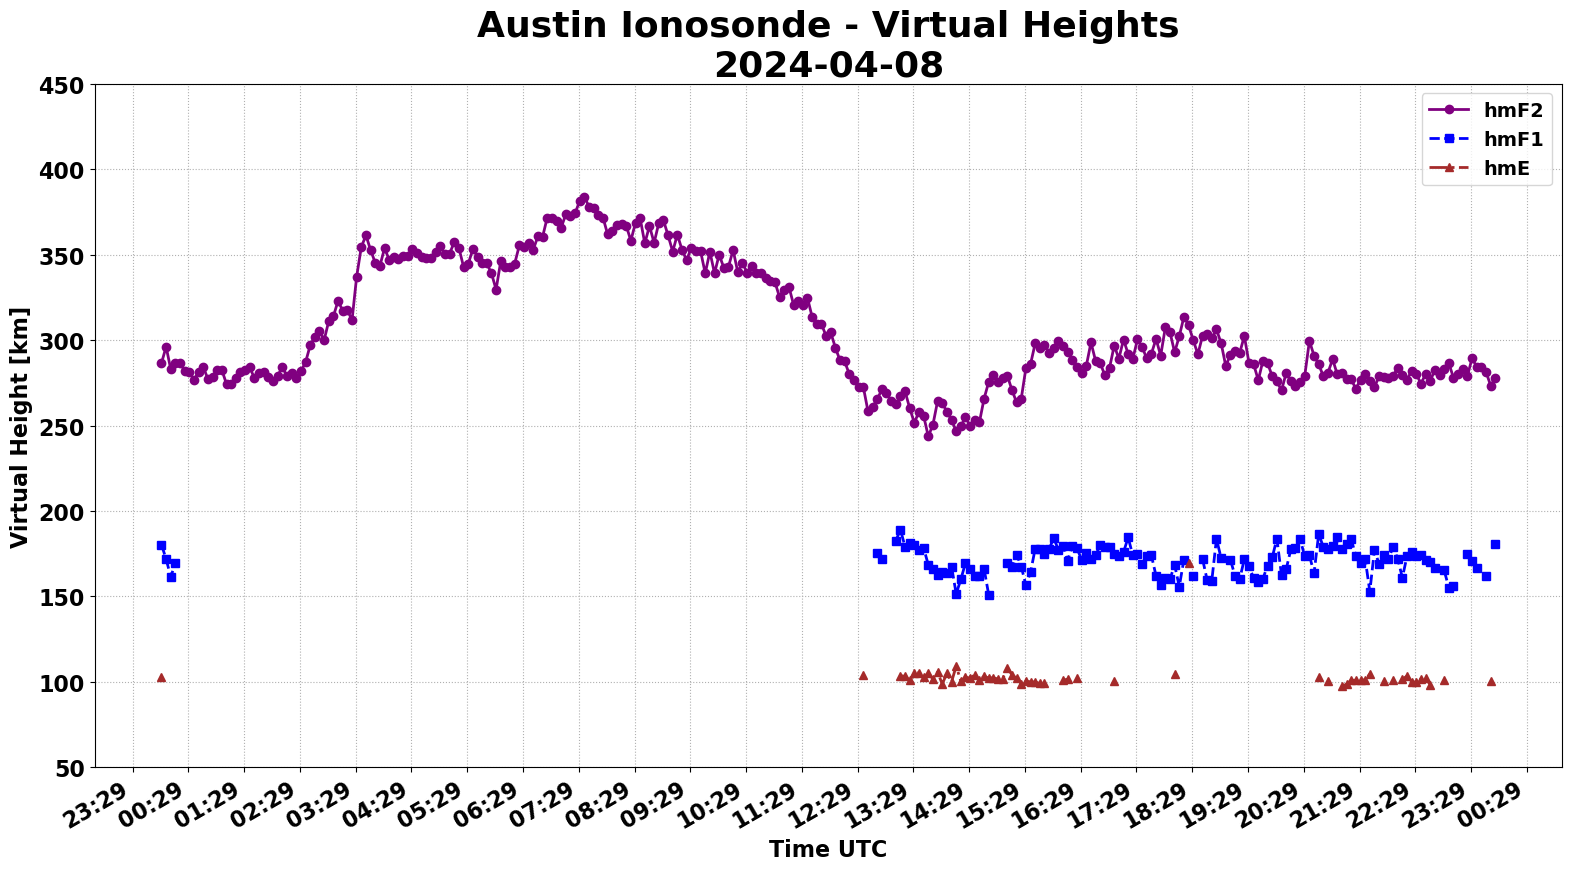

In [4]:
# Setup plotting style
import matplotlib as mpl
mpl.rcParams['font.size'] = 16
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.linestyle'] = ':'

fig, ax = plt.subplots(figsize=(16, 9))

# Plot virtual heights
ax.plot(ionosonde_df['UTC'], ionosonde_df['hmF2'], 
        label='hmF2', marker='o', linestyle='-', linewidth=2, color='purple')
ax.plot(ionosonde_df['UTC'], ionosonde_df['hmF1'], 
        label='hmF1', marker='s', linestyle='--', linewidth=2, color='blue')
ax.plot(ionosonde_df['UTC'], ionosonde_df['hmE'], 
        label='hmE', marker='^', linestyle='-.', linewidth=2, color='brown')

# Format the plot
ax.set_xlabel('Time UTC')
ax.set_ylabel('Virtual Height [km]')
ax.set_title('Austin Ionosonde - Virtual Heights\n2024-04-08', fontsize=26)
ax.legend(loc='best', fontsize=14)
ax.set_ylim(50, 450)

# Format datetime axis
myFmt = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(myFmt)
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig('validation_virtual_heights.jpg', dpi=300, bbox_inches='tight', format='jpeg', pil_kwargs={'quality': 95})
print("Saved: validation_virtual_heights.jpg")
plt.show()

## Plot Critical Frequencies

Plot foF2, foF1, and foE (critical frequencies of ionospheric layers).

Saved: validation_critical_frequencies.jpg


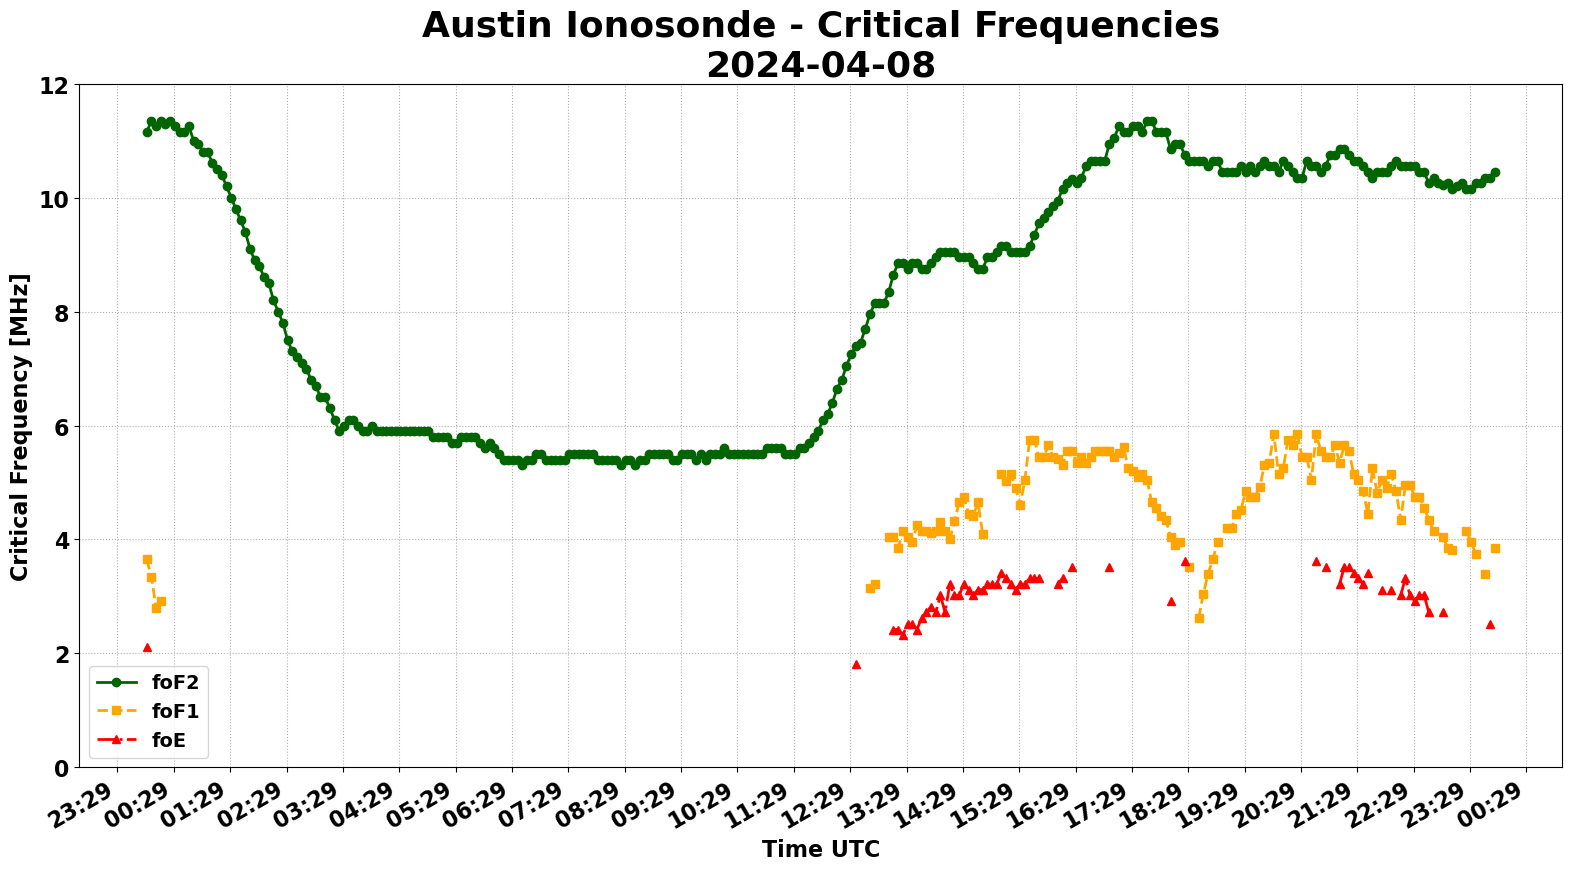

In [5]:
fig, ax = plt.subplots(figsize=(16, 9))

# Plot critical frequencies
ax.plot(ionosonde_df['UTC'], ionosonde_df['foF2'], 
        label='foF2', marker='o', linestyle='-', linewidth=2, color='darkgreen')
ax.plot(ionosonde_df['UTC'], ionosonde_df['foF1'], 
        label='foF1', marker='s', linestyle='--', linewidth=2, color='orange')
ax.plot(ionosonde_df['UTC'], ionosonde_df['foE'], 
        label='foE', marker='^', linestyle='-.', linewidth=2, color='red')

# Format the plot
ax.set_xlabel('Time UTC')
ax.set_ylabel('Critical Frequency [MHz]')
ax.set_title('Austin Ionosonde - Critical Frequencies\n2024-04-08', fontsize=26)
ax.legend(loc='best', fontsize=14)
ax.set_ylim(0, 12)

# Format datetime axis
myFmt = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(myFmt)
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig('validation_critical_frequencies.jpg', dpi=300, bbox_inches='tight', format='jpeg', pil_kwargs={'quality': 95})
print("Saved: validation_critical_frequencies.jpg")
plt.show()